## Análisis de reducción de dimensionalidad y segmentación de clientes mediante PCA y Clustering
### Descripción:
En este ejercicio se aplican técnicas de reducción de dimensionalidad mediante PCA y métodos de agrupamiento (Clustering) para analizar un conjunto de datos de clientes. Se busca identificar patrones y segmentar los datos en grupos con características similares a partir de las variables Edad, Ingresos y Experiencia.


In [1]:
import pandas as pd

# Crear DataFrame con las variables de la sección 3
df = pd.DataFrame({
    "Edad": [25, 40, 35, 50, 30],
    "Ingresos": [50000, 60000, 70000, 80000, 45000],
    "Experiencia": [2, 10, 7, 15, 3]
})

df

,Edad,Ingresos,Experiencia
0,25,50000,2
1,40,60000,10
2,35,70000,7
3,50,80000,15
4,30,45000,3


In [7]:
# Normalización de los datos

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = scaler.fit_transform(df)

df_scaled

array([[-1.27872403, -0.85895569, -1.13489465],
       [ 0.46499055, -0.07808688,  0.54643076],
       [-0.11624764,  0.70278193, -0.08406627],
       [ 1.62746694,  1.48365074,  1.59725914],
       [-0.69748583, -1.2493901 , -0.92472897]])

In [9]:
# Aplicar PCA para reducir a 2 componentes principales

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

df_pca = pca.fit_transform(df_scaled)

df_pca

array([[-1.89490798,  0.2506904 ],
       [ 0.54959063, -0.45743028],
       [ 0.275456  ,  0.66111219],
       [ 2.71995461, -0.04700849],
       [-1.65009327, -0.40736381]])

In [10]:
# Convertir el resultado de PCA en DataFrame
df_pca = pd.DataFrame(df_pca, columns=["PC1", "PC2"])

df_pca

,PC1,PC2
0,-1.894908,0.250690
1,0.549591,-0.457430
2,0.275456,0.661112
3,2.719955,-0.047008
4,-1.650093,-0.407364


In [11]:
# Aplicar K-Means Clustering

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)

df_pca["Cluster"] = kmeans.fit_predict(df_pca)

df_pca

,PC1,PC2,Cluster
0,-1.894908,0.250690,1
1,0.549591,-0.457430,0
2,0.275456,0.661112,0
3,2.719955,-0.047008,0
4,-1.650093,-0.407364,1


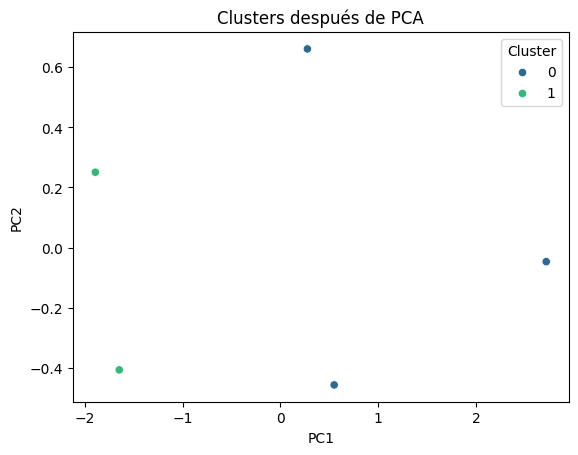

In [12]:
# Visualizar los clusters con un gráfico de dispersión (PC1 vs PC2).

import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=df_pca["PC1"], y=df_pca["PC2"], hue=df_pca["Cluster"], palette="viridis")

plt.title("Clusters después de PCA")

plt.show()

### Preguntas de reflexión y respuestas

### ¿Cuánta variabilidad explican las dos primeras componentes principales?
Las dos primeras componentes principales concentran la mayor parte de la variabilidad de los datos, permitiendo representar la información en dos dimensiones sin una pérdida significativa.
### ¿Cómo cambian los resultados de clustering después de aplicar PCA?
Los resultados se visualizan de forma más clara en un espacio reducido. El agrupamiento se mantiene, pero es más fácil identificar los grupos.
### ¿Qué conclusiones puedes extraer de los clusters obtenidos?
Se identifican dos grupos de clientes con características diferentes. Un grupo presenta valores más altos en las variables analizadas, mientras que el otro agrupa clientes con valores más bajos o moderados.
